In [1]:
import zipfile
import pandas as pd
import os

In [3]:
import zipfile
import os

zip_path = "/kaggle/input/datasets/anuragdawn/fdghhjh/fer2013.xls"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("fer2013_data")

print("extraction completed")
print(os.listdir("fer2013_data"))

extraction completed
['train', 'test']


In [4]:
for root,dirs,files in os.walk("fer2013_data"):
    print(root)
    if files:
        print(" Files:",files[:3])

fer2013_data
fer2013_data/train
fer2013_data/train/fear
 Files: ['Training_83212187.jpg', 'Training_41694221.jpg', 'Training_40388327.jpg']
fer2013_data/train/happy
 Files: ['Training_3232896.jpg', 'Training_11181996.jpg', 'Training_14058749.jpg']
fer2013_data/train/angry
 Files: ['Training_61529327.jpg', 'Training_10161559.jpg', 'Training_17363830.jpg']
fer2013_data/train/disgust
 Files: ['Training_91179471.jpg', 'Training_40939984.jpg', 'Training_96155311.jpg']
fer2013_data/train/neutral
 Files: ['Training_38868823.jpg', 'Training_17588579.jpg', 'Training_60189562.jpg']
fer2013_data/train/surprise
 Files: ['Training_37950463.jpg', 'Training_54841947.jpg', 'Training_29781564.jpg']
fer2013_data/train/sad
 Files: ['Training_24133132.jpg', 'Training_64643153.jpg', 'Training_73954004.jpg']
fer2013_data/test
fer2013_data/test/fear
 Files: ['PrivateTest_98837518.jpg', 'PublicTest_46279040.jpg', 'PrivateTest_82212504.jpg']
fer2013_data/test/happy
 Files: ['PrivateTest_63176014.jpg', 'Private

In [5]:
import tensorflow as tf
train_dir="fer2013_data/train"
test_dir="fer2013_data/test"
train_data=tf.keras.utils.image_dataset_from_directory(train_dir,image_size=(48,48),color_mode="grayscale",batch_size=32,shuffle=True)
test_data=tf.keras.utils.image_dataset_from_directory(test_dir,image_size=(48,48),color_mode="grayscale",batch_size=32,shuffle=False)
print(train_data.class_names)

Found 28709 files belonging to 7 classes.


I0000 00:00:1786391918.898485      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786391918.904696      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 7178 files belonging to 7 classes.
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [7]:
#preprocessing
normalization_layer=tf.keras.layers.Rescaling(1./255)
train_data=train_data.map(lambda x, y :(normalization_layer(x), y))
test_data=test_data.map(lambda x, y :(normalization_layer(x), y))

In [8]:
class_names=['angry','disgust','fear','happy','neutral','sad','suprise']

In [9]:
for images,labels in train_data.take(1):
    print(images.shape)
    print(images.numpy().min())
    print(images.numpy().max())

(32, 48, 48, 1)
0.0
0.003921569


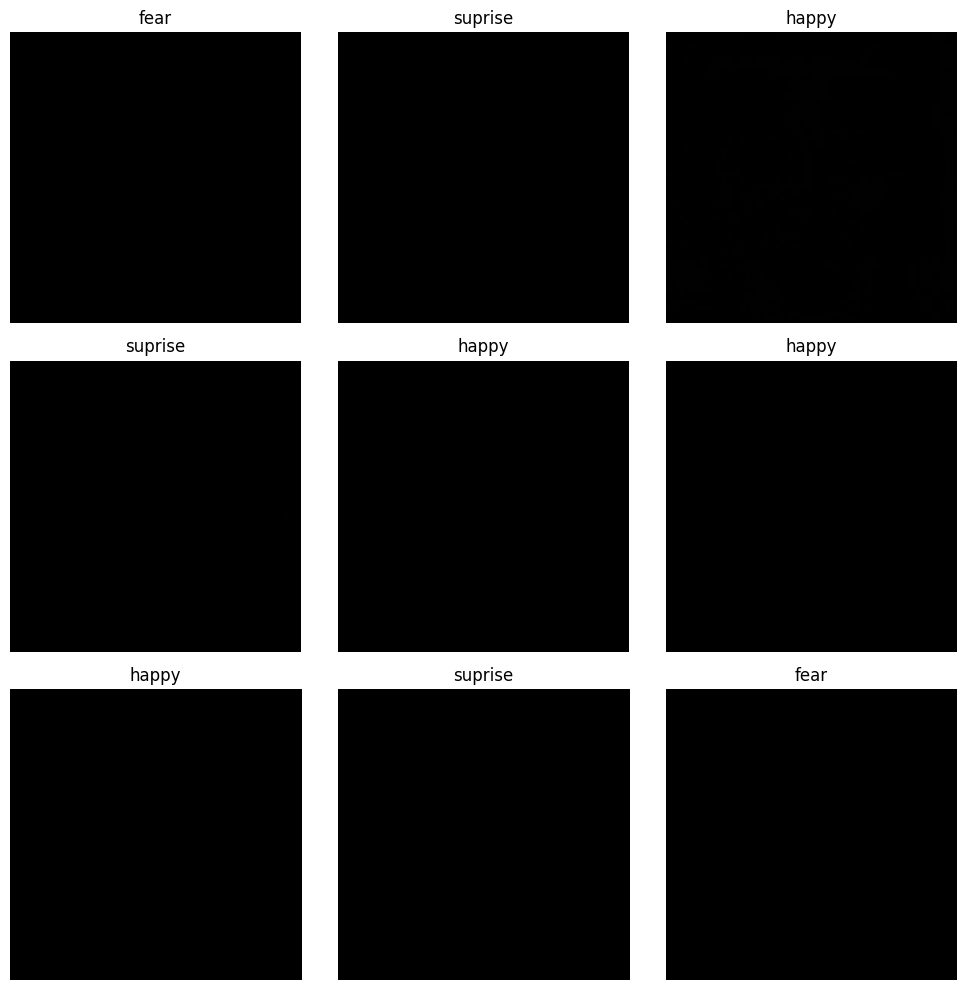

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
for i in range(9):
    for images,labels in train_data.take(1):
        plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().squeeze(),cmap='gray',vmin=0,vmax=1)
    plt.title(class_names[labels[i].numpy()])
    plt.axis('on')
plt.tight_layout()
plt.show()

In [11]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [12]:
#model building
import tensorflow as tf
model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(48, 48, 1)),

    # Data augmentation
    data_augmentation,

    # =========================
    # BLOCK 1
    # =========================
    tf.keras.layers.Conv2D(
        32, (3, 3),
        padding='same',
        use_bias=False
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),

    tf.keras.layers.Conv2D(
        32, (3, 3),
        padding='same',
        use_bias=False
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),

    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.20),

    # =========================
    # BLOCK 2
    # =========================
    tf.keras.layers.Conv2D(
        64, (3, 3),
        padding='same',
        use_bias=False
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),

    tf.keras.layers.Conv2D(
        64, (3, 3),
        padding='same',
        use_bias=False
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),

    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),

    # =========================
    # BLOCK 3
    # =========================
    tf.keras.layers.Conv2D(
        128, (3, 3),
        padding='same',
        use_bias=False
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),

    tf.keras.layers.Conv2D(
        128, (3, 3),
        padding='same',
        use_bias=False
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),

    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.30),

    # =========================
    # CLASSIFICATION
    # =========================
    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.40),

    # 7 FER-2013 classes
    tf.keras.layers.Dense(7, activation='softmax')
])

In [13]:
import tensorflow as tf
print("tenserflow:",tf.__version__)
print("GPU:",tf.config.list_physical_devices('GPU'))

tenserflow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [14]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )
]

In [15]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),loss=tf.keras.losses.SparseCategoricalCrossentropy(),metrics=['accuracy'])

In [16]:
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

checkpoint = ModelCheckpoint(
    "best_fer2013_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=8,
    mode="max",
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=75,
    callbacks=[
        checkpoint,
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/75


E0000 00:00:1786392020.791868      59 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2031 - loss: 2.0897
Epoch 1: val_accuracy improved from None to 0.18362, saving model to best_fer2013_model.keras

Epoch 1: finished saving model to best_fer2013_model.keras
898/898 ━━━━━━━━━━━━━━━━━━━━ 28s 21ms/step - accuracy: 0.2171 - loss: 1.9663 - val_accuracy: 0.1836 - val_loss: 1.9715 - learning_rate: 0.0010
Epoch 2/75
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2700 - loss: 1.7859
Epoch 2: val_accuracy did not improve from 0.18362
898/898 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.2910 - loss: 1.7420 - val_accuracy: 0.1453 - val_loss: 2.8246 - learning_rate: 0.0010
Epoch 3/75
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3840 - loss: 1.5719
Epoch 3: val_accuracy improved from 0.18362 to 0.37852, saving model to best_fer2013_model.keras

Epoch 3: finished saving model to best_fer2013_model.keras
898/898 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.4017 - loss: 1.5394 - val_accuracy: 0.3785 - 

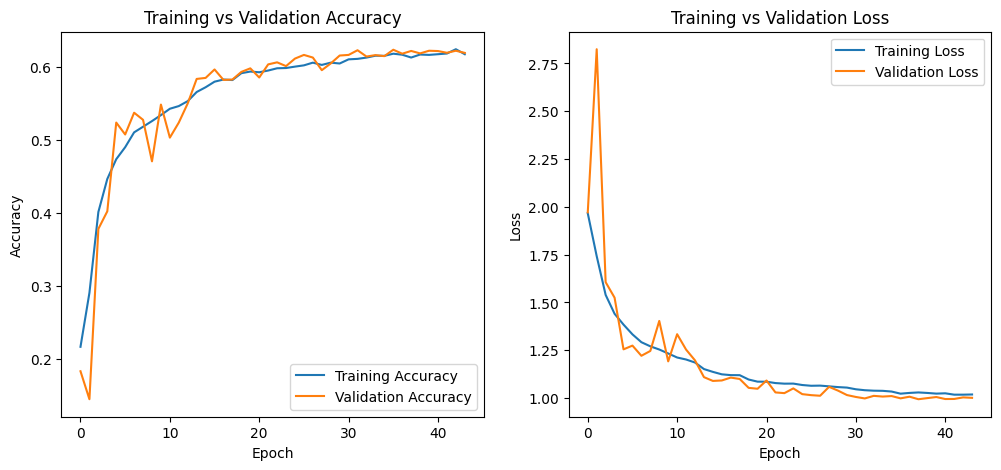

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()


plt.subplot(1, 2, 2)

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [19]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_data:
    predictions = model.predict(images, verbose=0)

    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [20]:
y_true=np.array(y_true)
y_pred=np.array(y_pred)
print(y_true.shape , y_pred.shape)

(7178,) (7178,)


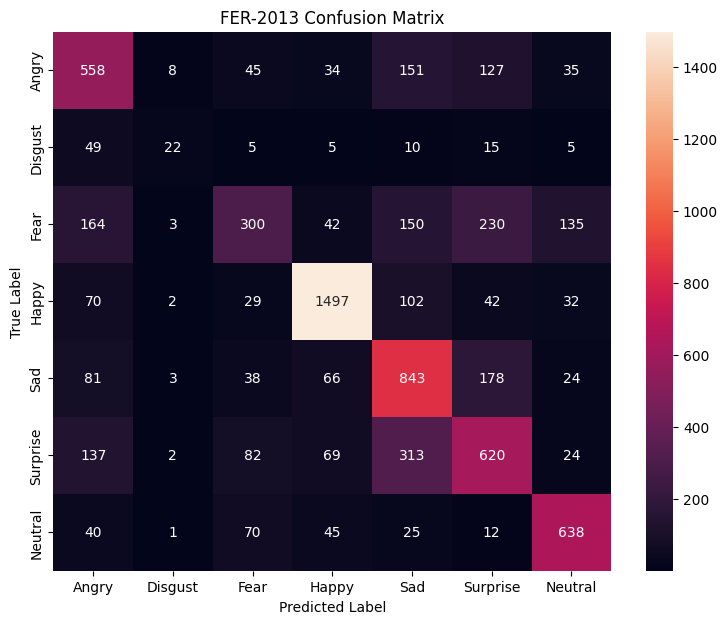

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

class_names = [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Sad",
    "Surprise",
    "Neutral"
]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("FER-2013 Confusion Matrix")

plt.show()

In [22]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

       Angry       0.51      0.58      0.54       958
     Disgust       0.54      0.20      0.29       111
        Fear       0.53      0.29      0.38      1024
       Happy       0.85      0.84      0.85      1774
         Sad       0.53      0.68      0.60      1233
    Surprise       0.51      0.50      0.50      1247
     Neutral       0.71      0.77      0.74       831

    accuracy                           0.62      7178
   macro avg       0.60      0.55      0.56      7178
weighted avg       0.62      0.62      0.62      7178



In [23]:
import pandas as pd
import os

file_path = "/kaggle/input/datasets/joebeachcapital/top-10000-spotify-songs-1960-now/top_10000_1950-now.csv"

try:
    # Read the CSV file instead of trying to extract it as a zip
    df = pd.read_csv(file_path)
    print("CSV file loaded successfully.")
    print("First 5 rows of the DataFrame:")
    print(df.head())
except Exception as e:
    print(f"Error reading CSV file: {e}")

CSV file loaded successfully.
First 5 rows of the DataFrame:
                              Track URI                           Track Name  \
0  spotify:track:0vNPJrUrBnMFdCs8b2MTNG                                Fader   
1  spotify:track:0NpvdCO506uO58D4AbKzki                               Sherry   
2  spotify:track:1MtUq6Wp1eQ8PC6BbPCj8P  I Took A Pill In Ibiza - Seeb Remix   
3  spotify:track:59lq75uFIqzUZcgZ4CbqFG                   Let Go for Tonight   
4  spotify:track:7KdcZQ3GJeGdserhK61kfv          The Way I Want To Touch You   

                                       Artist URI(s)  \
0              spotify:artist:4W48hZAnAHVOC2c8WH8pcq   
1              spotify:artist:6mcrZQmgzFGRWf7C0SObou   
2  spotify:artist:2KsP6tYLJlTBvSUxnwlVWa, spotify...   
3              spotify:artist:7qRll6DYV06u2VuRPAVqug   
4              spotify:artist:7BEfMxbaqx6dOpbtlEqScm   

                     Artist Name(s)                             Album URI  \
0                   The Temper Trap  spotify

In [24]:
print(df.shape)

(10000, 35)


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Track URI             10000 non-null  object 
 1   Track Name            9998 non-null   object 
 2   Artist URI(s)         9998 non-null   object 
 3   Artist Name(s)        9998 non-null   object 
 4   Album URI             9998 non-null   object 
 5   Album Name            9998 non-null   object 
 6   Album Artist URI(s)   9998 non-null   object 
 7   Album Artist Name(s)  9998 non-null   object 
 8   Album Release Date    9998 non-null   object 
 9   Album Image URL       9996 non-null   object 
 10  Disc Number           10000 non-null  int64  
 11  Track Number          10000 non-null  int64  
 12  Track Duration (ms)   10000 non-null  int64  
 13  Track Preview URL     9937 non-null   object 
 14  Explicit              10000 non-null  bool   
 15  Popularity          

In [26]:
# Make a copy
spotify = df.copy()

# Remove the completely empty column
spotify = spotify.drop(columns=["Album Genres"])

# Keep only columns useful for our project
spotify = spotify[
    [
        "Track URI",
        "Track Name",
        "Artist Name(s)",
        "Album Name",
        "Popularity",
        "Artist Genres",
        "Danceability",
        "Energy",
        "Loudness",
        "Speechiness",
        "Acousticness",
        "Instrumentalness",
        "Liveness",
        "Valence",
        "Tempo"
    ]
]

# Remove rows with missing audio features
audio_features = [
    "Danceability",
    "Energy",
    "Loudness",
    "Speechiness",
    "Acousticness",
    "Instrumentalness",
    "Liveness",
    "Valence",
    "Tempo"
]

spotify = spotify.dropna(subset=audio_features)

# Reset index
spotify = spotify.reset_index(drop=True)

print("Dataset shape:", spotify.shape)
spotify.head()

Dataset shape: (9995, 15)


,Track URI,Track Name,Artist Name(s),Album Name,Popularity,Artist Genres,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo
0,spotify:track:0vNPJrUrBnMFdCs8b2MTNG,Fader,The Temper Trap,Conditions (Tour Edition),0,"indietronica,modern rock,shimmer pop",0.532,0.760,-7.123,0.0353,0.000101,0.690000,0.0752,0.158,134.974
1,spotify:track:0NpvdCO506uO58D4AbKzki,Sherry,Frankie Valli & The Four Seasons,The Very Best of Frankie Valli & The 4 Seasons,54,"adult standards,bubblegum pop,doo-wop,lounge,n...",0.703,0.478,-8.062,0.0441,0.626000,0.000000,0.1130,0.734,117.562
2,spotify:track:1MtUq6Wp1eQ8PC6BbPCj8P,I Took A Pill In Ibiza - Seeb Remix,"Mike Posner, Seeb","At Night, Alone.",63,"dance pop,pop,pop dance,pop rap,pop dance",0.664,0.714,-6.645,0.1110,0.035300,0.000008,0.0843,0.710,101.969
3,spotify:track:59lq75uFIqzUZcgZ4CbqFG,Let Go for Tonight,Foxes,Glorious (Deluxe),39,"electropop,metropopolis,uk pop",0.543,0.808,-6.615,0.0632,0.042900,0.000002,0.3260,0.299,140.064
4,spotify:track:7KdcZQ3GJeGdserhK61kfv,The Way I Want To Touch You,Captain & Tennille,Love Will Keep Us Together,35,"mellow gold,soft rock,yacht rock",0.664,0.585,-7.062,0.0248,0.624000,0.000112,0.3430,0.597,111.290


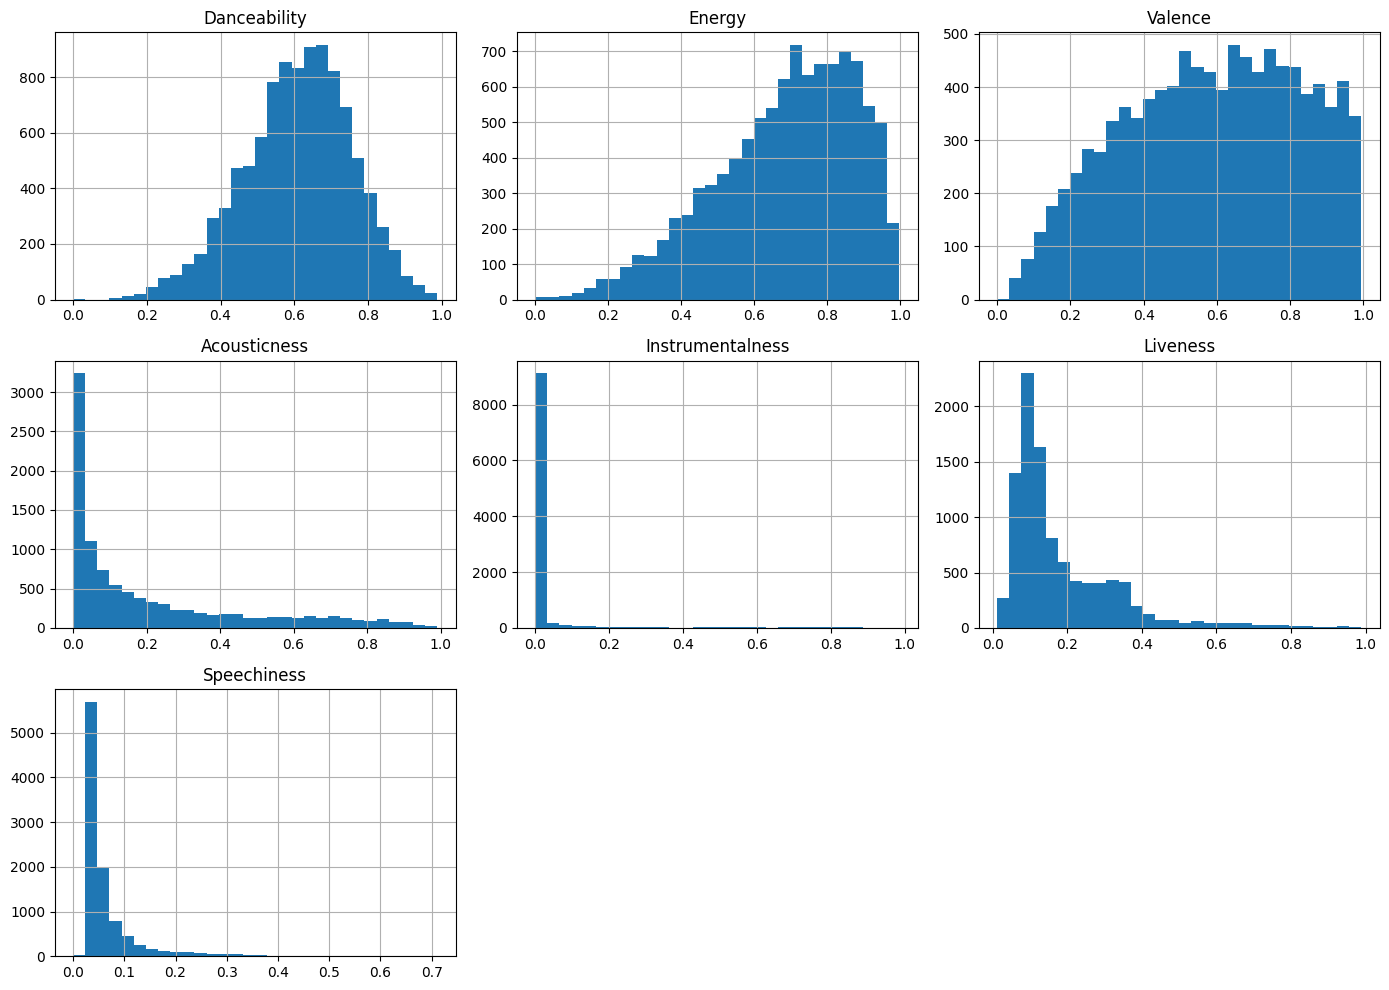

In [27]:
import matplotlib.pyplot as plt

features = [
    "Danceability",
    "Energy",
    "Valence",
    "Acousticness",
    "Instrumentalness",
    "Liveness",
    "Speechiness"
]

spotify[features].hist(
    figsize=(14, 10),
    bins=30
)

plt.tight_layout()
plt.show()

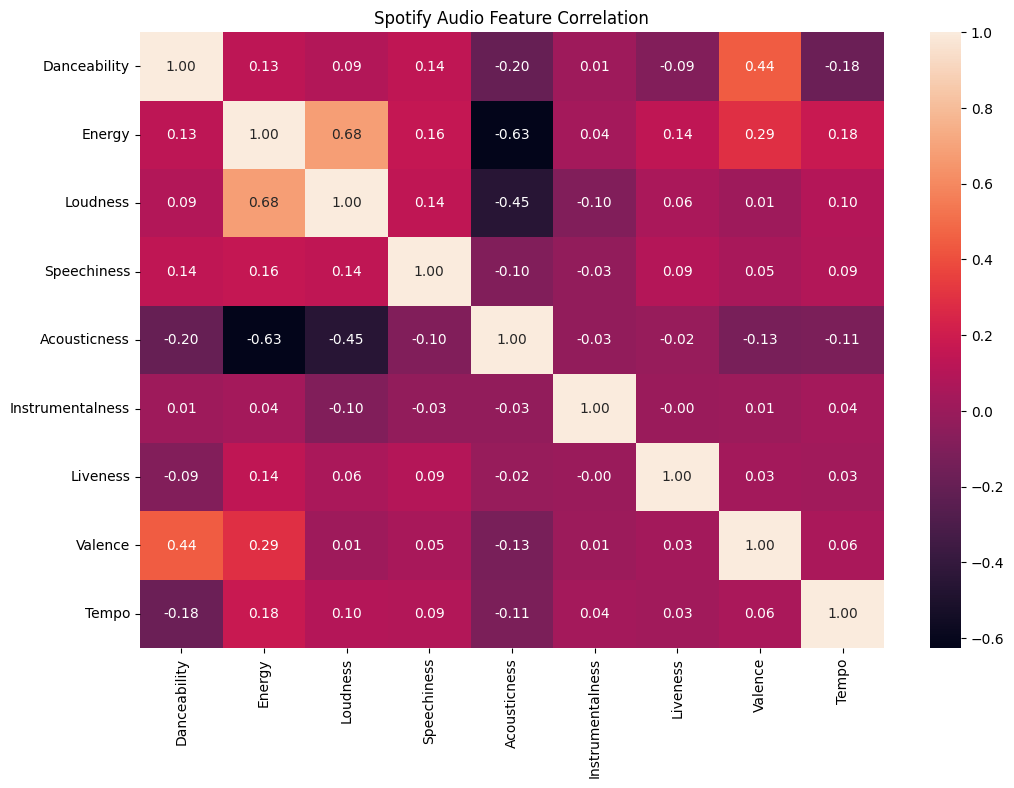

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_features = [
    "Danceability",
    "Energy",
    "Loudness",
    "Speechiness",
    "Acousticness",
    "Instrumentalness",
    "Liveness",
    "Valence",
    "Tempo"
]

plt.figure(figsize=(12, 8))

sns.heatmap(
    spotify[corr_features].corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Spotify Audio Feature Correlation")
plt.show()

In [29]:
mood_profiles = {
    "Happy": {
        "Danceability": 0.75,
        "Energy": 0.80,
        "Loudness": -5.0,
        "Speechiness": 0.08,
        "Acousticness": 0.20,
        "Instrumentalness": 0.05,
        "Liveness": 0.15,
        "Valence": 0.85,
        "Tempo": 120
    },

    "Sad": {
        "Danceability": 0.45,
        "Energy": 0.35,
        "Loudness": -10.0,
        "Speechiness": 0.05,
        "Acousticness": 0.65,
        "Instrumentalness": 0.10,
        "Liveness": 0.12,
        "Valence": 0.25,
        "Tempo": 80
    },

    "Angry": {
        "Danceability": 0.55,
        "Energy": 0.90,
        "Loudness": -4.0,
        "Speechiness": 0.12,
        "Acousticness": 0.10,
        "Instrumentalness": 0.10,
        "Liveness": 0.20,
        "Valence": 0.30,
        "Tempo": 135
    },

    "Calm": {
        "Danceability": 0.40,
        "Energy": 0.25,
        "Loudness": -12.0,
        "Speechiness": 0.04,
        "Acousticness": 0.75,
        "Instrumentalness": 0.20,
        "Liveness": 0.10,
        "Valence": 0.50,
        "Tempo": 70
    },

    "Fear": {
        "Danceability": 0.35,
        "Energy": 0.55,
        "Loudness": -8.0,
        "Speechiness": 0.06,
        "Acousticness": 0.45,
        "Instrumentalness": 0.15,
        "Liveness": 0.15,
        "Valence": 0.20,
        "Tempo": 100
    },

    "Surprise": {
        "Danceability": 0.80,
        "Energy": 0.85,
        "Loudness": -5.0,
        "Speechiness": 0.10,
        "Acousticness": 0.20,
        "Instrumentalness": 0.05,
        "Liveness": 0.20,
        "Valence": 0.75,
        "Tempo": 130
    },

    "Neutral": {
        "Danceability": 0.55,
        "Energy": 0.55,
        "Loudness": -7.0,
        "Speechiness": 0.06,
        "Acousticness": 0.40,
        "Instrumentalness": 0.10,
        "Liveness": 0.15,
        "Valence": 0.50,
        "Tempo": 100
    }
}

In [30]:
from sklearn.preprocessing import StandardScaler
import numpy as np

features = [
    "Danceability",
    "Energy",
    "Loudness",
    "Speechiness",
    "Acousticness",
    "Instrumentalness",
    "Liveness",
    "Valence",
    "Tempo"
]

# Create a completely new scaler
scaler = StandardScaler()

# Convert Spotify features to NumPy BEFORE fitting
X = spotify[features].to_numpy()

# Fit scaler
spotify_scaled = scaler.fit_transform(X)

print("Shape:", spotify_scaled.shape)

Shape: (9995, 9)


In [31]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_songs(emotion, n=10):

    if emotion not in mood_profiles:
        raise ValueError(f"Unknown emotion: {emotion}")

    # Create mood vector
    mood_vector = np.array([
        [mood_profiles[emotion][feature] for feature in features]
    ])

    # Scale using the SAME scaler
    mood_scaled = scaler.transform(mood_vector)

    # Calculate similarity
    similarity = cosine_similarity(
        mood_scaled,
        spotify_scaled
    )[0]

    # Get top songs
    top_indices = np.argsort(similarity)[::-1][:n]

    recommendations = spotify.iloc[top_indices].copy()

    recommendations["Similarity"] = similarity[top_indices]

    return recommendations[
        [
            "Track Name",
            "Artist Name(s)",
            "Popularity",
            "Similarity"
        ]
    ]

In [32]:
recommend_songs('Happy',10)

,Track Name,Artist Name(s),Popularity,Similarity
7385,Own This Club,Marvin Priest,30,0.950091
5402,Car Wash (Shark Tale Mix),"Christina Aguilera, Missy Elliott",0,0.942672
5209,Wrapped Up (feat. Travie McCoy),"Olly Murs, Travie McCoy",0,0.939013
2797,Boom Boom,Justice Crew,47,0.932703
7688,Ride It,Regard,80,0.932002
7743,Heart Skips a Beat (feat. Rizzle Kicks),"Olly Murs, Rizzle Kicks",59,0.928780
4244,Black or White - Single Version,Michael Jackson,56,0.922849
8736,I'm a Slave 4 U,Britney Spears,69,0.922837
2478,Flava,Nathaniel,2,0.922674
4464,Poker Face,Lady Gaga,0,0.922135


## Mood Assignment — Profile-Based (replaces KMeans + PCA)

The unsupervised KMeans clusters didn't line up cleanly with the 7 target moods when visualized with PCA (heavy overlap between clusters), and the cluster-to-mood names were being assigned by hand anyway with no guarantee they were right.

Since we already defined Spotify feature profiles for every mood (`mood_profiles`), we skip clustering entirely: each song is assigned directly to whichever mood profile it is closest to (cosine similarity, same scaled feature space used everywhere else). This is deterministic, grounded in the profiles we designed, and has no overlapping-cluster ambiguity to visualize in the first place.


In [33]:
from sklearn.metrics.pairwise import cosine_similarity

# Every song gets assigned to whichever mood profile (from mood_profiles) it is
# most similar to, in the same scaled feature space used everywhere else.
# This replaces unsupervised KMeans clustering: instead of forming data-driven
# clusters and then guessing which cluster corresponds to which mood, we go
# straight from "features we set for every mood" -> "closest mood per song".

mood_names = list(mood_profiles.keys())

mood_matrix = np.array([
    [mood_profiles[mood][feature] for feature in features]
    for mood in mood_names
])

mood_matrix_scaled = scaler.transform(mood_matrix)

# Similarity of every song to every mood profile
song_mood_similarity = cosine_similarity(spotify_scaled, mood_matrix_scaled)

best_mood_idx = np.argmax(song_mood_similarity, axis=1)

spotify["Mood"] = [mood_names[i] for i in best_mood_idx]
spotify["Mood_Similarity"] = song_mood_similarity[
    np.arange(len(spotify)), best_mood_idx
]

print(spotify["Mood"].value_counts())


Mood
Happy       2563
Angry       2437
Surprise    1359
Calm        1267
Sad         1182
Fear         852
Neutral      335
Name: count, dtype: int64


In [34]:
# Sanity check: does the average feature vector of the songs assigned to each
# mood actually match the profile we defined for that mood?
mood_check = spotify.groupby("Mood")[features].mean().round(2)
mood_check["Song_Count"] = spotify["Mood"].value_counts()

target_profiles = pd.DataFrame(mood_profiles).T[features].round(2)
target_profiles.columns = [f"Target_{c}" for c in target_profiles.columns]

mood_check.join(target_profiles).reindex(mood_names)


,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Song_Count,Target_Danceability,Target_Energy,Target_Loudness,Target_Speechiness,Target_Acousticness,Target_Instrumentalness,Target_Liveness,Target_Valence,Target_Tempo
Mood,,,,,,,,,,,,,,,,,,,
Happy,0.70,0.76,-6.33,0.05,0.12,0.02,0.13,0.81,117.51,2563,0.75,0.80,-5.0,0.08,0.20,0.05,0.15,0.85,120.0
Sad,0.54,0.42,-9.91,0.05,0.52,0.00,0.16,0.32,107.39,1182,0.45,0.35,-10.0,0.05,0.65,0.10,0.12,0.25,80.0
Angry,0.54,0.82,-5.20,0.09,0.06,0.04,0.21,0.45,135.66,2437,0.55,0.90,-4.0,0.12,0.10,0.10,0.20,0.30,135.0
Calm,0.59,0.49,-11.90,0.05,0.43,0.05,0.18,0.71,115.69,1267,0.40,0.25,-12.0,0.04,0.75,0.20,0.10,0.50,70.0
Fear,0.43,0.61,-7.48,0.04,0.21,0.05,0.18,0.33,122.49,852,0.35,0.55,-8.0,0.06,0.45,0.15,0.15,0.20,100.0
Surprise,0.73,0.78,-6.15,0.11,0.13,0.02,0.28,0.69,127.86,1359,0.80,0.85,-5.0,0.10,0.20,0.05,0.20,0.75,130.0
Neutral,0.64,0.61,-6.11,0.05,0.32,0.08,0.15,0.52,93.43,335,0.55,0.55,-7.0,0.06,0.40,0.10,0.15,0.50,100.0


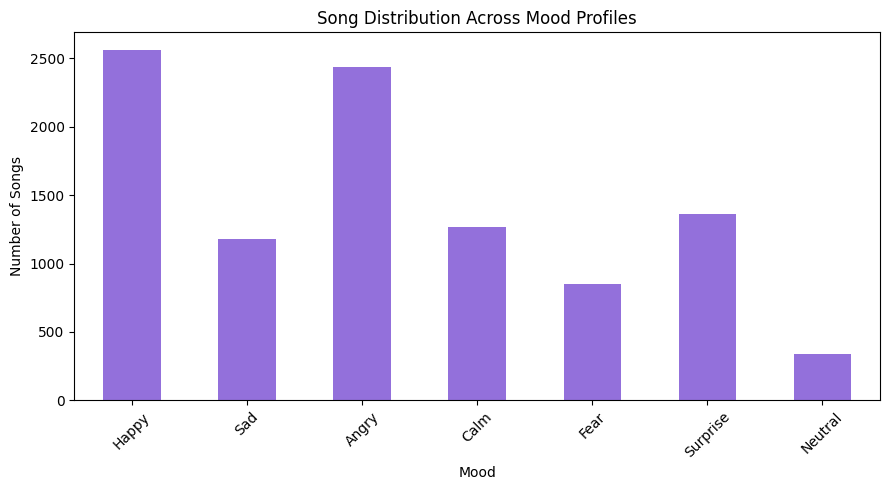

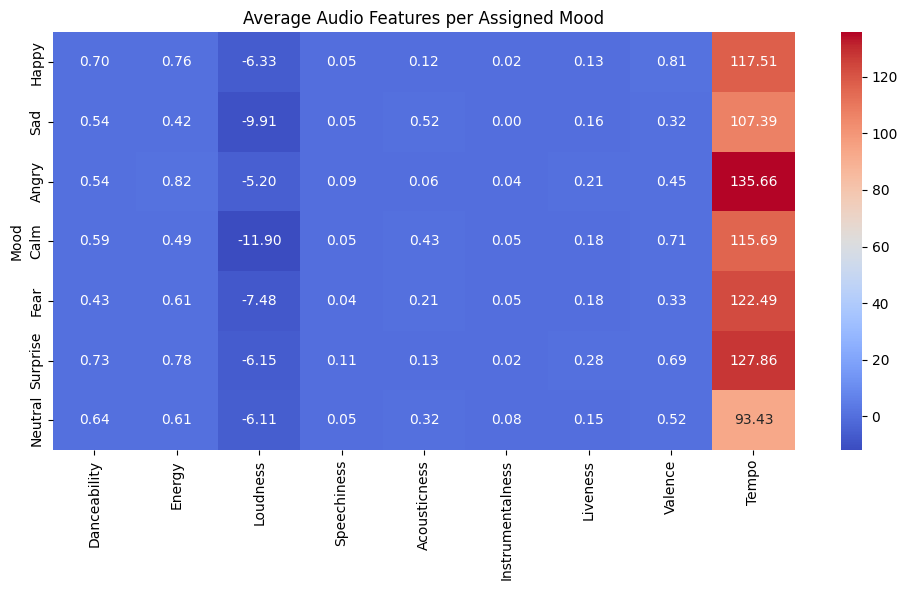

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# How many songs landed in each mood bucket
mood_counts = spotify["Mood"].value_counts().reindex(mood_names)

plt.figure(figsize=(9, 5))
mood_counts.plot(kind="bar", color="mediumpurple")
plt.xlabel("Mood")
plt.ylabel("Number of Songs")
plt.title("Song Distribution Across Mood Profiles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# How distinct the moods actually are along each audio feature
plt.figure(figsize=(10, 6))
sns.heatmap(
    spotify.groupby("Mood")[features].mean().reindex(mood_names),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Average Audio Features per Assigned Mood")
plt.tight_layout()
plt.show()


In [37]:
spotify[["Track Name", "Artist Name(s)", "Mood", "Mood_Similarity"]].head(10)


,Track Name,Artist Name(s),Mood,Mood_Similarity
0,Fader,The Temper Trap,Fear,0.443853
1,Sherry,Frankie Valli & The Four Seasons,Calm,0.548784
2,I Took A Pill In Ibiza - Seeb Remix,"Mike Posner, Seeb",Happy,0.537547
3,Let Go for Tonight,Foxes,Angry,0.669648
4,The Way I Want To Touch You,Captain & Tennille,Sad,0.434771
5,Still Got Time (feat. PARTYNEXTDOOR),"ZAYN, PARTYNEXTDOOR",Surprise,0.361904
6,Your Song,Rita Ora,Happy,0.744293
7,Fix You,Coldplay,Fear,0.733771
8,There You'll Be - 2007 Remaster,Faith Hill,Fear,0.832606
9,Every Breath You Take - Remastered 2003,The Police,Calm,0.443993


In [38]:
# Keys must match the exact strings predict_emotion() returns (i.e. class_names
# above), mapped to the mood_profiles keys used to build the "Mood" column.
emotion_to_mood = {
    "angry": "Angry",
    "disgust": "Angry",    # negative valence + raised arousal, closest to Angry
    "fear": "Fear",
    "happy": "Happy",
    "neutral": "Neutral",
    "sad": "Sad",
    "suprise": "Surprise"  # spelling kept consistent with class_names above
}


In [39]:
def recommend_by_emotion(emotion, n=10):

    if emotion not in emotion_to_mood:
        raise ValueError(f"Unknown emotion: {emotion}")

    mood = emotion_to_mood[emotion]

    results = spotify[
        spotify["Mood"] == mood
    ].sort_values(
        by="Popularity",
        ascending=False
    ).head(n)

    return results[
        [
            "Track Name",
            "Artist Name(s)",
            "Popularity",
            "Mood"
        ]
    ]

In [41]:
recommend_by_emotion("happy", 10)

,Track Name,Artist Name(s),Popularity,Mood
1347,Espresso,Sabrina Carpenter,94,Happy
9682,That's What I Like,Bruno Mars,86,Happy
8083,Unwritten,Natasha Bedingfield,86,Happy
1332,Take on Me,a-ha,86,Happy
969,All The Stars (with SZA),"Kendrick Lamar, SZA",85,Happy
8790,Dreams - 2004 Remaster,Fleetwood Mac,85,Happy
7908,Shape of You,Ed Sheeran,85,Happy
9284,Hold the Line,TOTO,84,Happy
5051,"Hey, Soul Sister",Train,84,Happy
4825,Houdini,Eminem,84,Happy


In [43]:
# 60 emotion and 40 popularity
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

def recommend_by_emotion(emotion, n=10):

    if emotion not in emotion_to_mood:
        raise ValueError(f"Unknown emotion: {emotion}")

    mood = emotion_to_mood[emotion]

    # Get songs belonging to the required mood
    mood_songs = spotify[spotify["Mood"] == mood].copy()

    if len(mood_songs) == 0:
        return pd.DataFrame()

    # Create mood vector
    mood_vector = np.array([
        [mood_profiles[mood][feature] for feature in features]
    ])

    # Get features of mood songs
    song_features = mood_songs[features].to_numpy()

    # Scale them using our existing scaler
    song_scaled = scaler.transform(song_features)
    mood_scaled = scaler.transform(mood_vector)

    # Calculate similarity
    similarities = cosine_similarity(
        mood_scaled,
        song_scaled
    )[0]

    mood_songs["Similarity"] = similarities

    # Normalize popularity to 0-1
    mood_songs["Popularity_Score"] = (
        mood_songs["Popularity"] / 100
    )

    # Combined recommendation score
    mood_songs["Recommendation_Score"] = (
        0.6 * mood_songs["Similarity"]
        + 0.4 * mood_songs["Popularity_Score"]
    )

    # Sort by final score
    recommendations = mood_songs.sort_values(
        "Recommendation_Score",
        ascending=False
    ).head(n)

    return recommendations[
        [
            "Track Name",
            "Artist Name(s)",
            "Popularity",
            "Similarity",
            "Recommendation_Score",
            "Mood"
        ]
    ]

In [44]:
recommend_by_emotion("happy", 10)

,Track Name,Artist Name(s),Popularity,Similarity,Recommendation_Score,Mood
3724,There's Nothing Holdin' Me Back,Shawn Mendes,84,0.914049,0.884429,Happy
4825,Houdini,Eminem,84,0.909216,0.881529,Happy
7688,Ride It,Regard,80,0.932002,0.879201,Happy
72,Poker Face,Lady Gaga,81,0.908400,0.869040,Happy
2961,Head & Heart (feat. MNEK),"Joel Corry, MNEK",75,0.909870,0.845922,Happy
6766,Promiscuous,"Nelly Furtado, Timbaland",82,0.850877,0.838526,Happy
2781,What Makes You Beautiful,One Direction,82,0.848207,0.836924,Happy
2163,All About That Bass,Meghan Trainor,72,0.912374,0.835424,Happy
3540,"Whenever, Wherever",Shakira,76,0.879927,0.831956,Happy
3413,I Was Made For Lovin' You,KISS,81,0.844721,0.830832,Happy


In [45]:
recommend_by_emotion("sad", 10)

,Track Name,Artist Name(s),Popularity,Similarity,Recommendation_Score,Mood
2856,I Will Always Love You,Whitney Houston,77,0.973426,0.892056,Sad
682,When I Was Your Man,Bruno Mars,88,0.883292,0.881975,Sad
1141,Imagine - Remastered 2010,John Lennon,76,0.959027,0.879416,Sad
5453,lovely (with Khalid),"Billie Eilish, Khalid",86,0.886513,0.875908,Sad
1661,Stay With Me,Sam Smith,82,0.912311,0.875387,Sad
1107,Arcade,Duncan Laurence,73,0.956337,0.865802,Sad
9970,Come Away With Me,Norah Jones,71,0.958457,0.859074,Sad
9466,Photograph,Ed Sheeran,84,0.870688,0.858413,Sad
5233,"My Heart Will Go On - Love Theme from ""Titanic""",Céline Dion,73,0.933449,0.852069,Sad
2350,Can't Help Falling in Love,Elvis Presley,79,0.893223,0.851934,Sad


In [46]:
recommend_by_emotion("angry", 10)

,Track Name,Artist Name(s),Popularity,Similarity,Recommendation_Score,Mood
7671,Titanium (feat. Sia),"David Guetta, Sia",80,0.893096,0.855858,Angry
1216,Highway to Hell,AC/DC,84,0.832860,0.835716,Angry
7424,Uprising,Muse,75,0.856025,0.813615,Angry
9632,By the Way,Red Hot Chili Peppers,75,0.844911,0.806946,Angry
221,Silence,"Marshmello, Khalid",81,0.790148,0.798089,Angry
6321,Don't Let Me Down,"The Chainsmokers, Daya",81,0.787615,0.796569,Angry
2841,Castle on the Hill,Ed Sheeran,78,0.784513,0.782708,Angry
9151,Higher Ground - Remastered 2003,Red Hot Chili Peppers,65,0.864113,0.778468,Angry
1823,Kids,MGMT,77,0.780920,0.776552,Angry
6731,Thunderstruck,AC/DC,84,0.733833,0.776300,Angry


In [48]:
recommend_by_emotion("suprise", 10)

,Track Name,Artist Name(s),Popularity,Similarity,Recommendation_Score,Mood
3696,Toxic,Britney Spears,84,0.890273,0.870164,Surprise
4882,Friday (feat. Mufasa & Hypeman) - Dopamine Re-...,"Riton, Nightcrawlers, Mufasa & Hypeman, Mufasa...",76,0.889503,0.837702,Surprise
6543,TiK ToK,Kesha,83,0.831925,0.831155,Surprise
9661,Believer,Imagine Dragons,86,0.799672,0.823803,Surprise
3840,Who Let The Dogs Out,Baha Men,64,0.945210,0.823126,Surprise
5939,Rasputin,"Majestic, Boney M.",78,0.851795,0.823077,Surprise
3483,Say It Right,Nelly Furtado,78,0.826487,0.807892,Surprise
8208,We Are Family - 1995 Remaster,Sister Sledge,67,0.899353,0.807612,Surprise
4373,Gettin' Jiggy Wit It,Will Smith,70,0.877406,0.806444,Surprise
7240,Don't Start Now,Dua Lipa,81,0.799811,0.803887,Surprise


In [49]:
import joblib

joblib.dump(scaler, "spotify_scaler.pkl")

print("Scaler saved successfully!")


Scaler saved successfully!


In [50]:
emotion = "happy"

recommendations = recommend_by_emotion(
    emotion,
    10
)

recommendations

,Track Name,Artist Name(s),Popularity,Similarity,Recommendation_Score,Mood
3724,There's Nothing Holdin' Me Back,Shawn Mendes,84,0.914049,0.884429,Happy
4825,Houdini,Eminem,84,0.909216,0.881529,Happy
7688,Ride It,Regard,80,0.932002,0.879201,Happy
72,Poker Face,Lady Gaga,81,0.908400,0.869040,Happy
2961,Head & Heart (feat. MNEK),"Joel Corry, MNEK",75,0.909870,0.845922,Happy
6766,Promiscuous,"Nelly Furtado, Timbaland",82,0.850877,0.838526,Happy
2781,What Makes You Beautiful,One Direction,82,0.848207,0.836924,Happy
2163,All About That Bass,Meghan Trainor,72,0.912374,0.835424,Happy
3540,"Whenever, Wherever",Shakira,76,0.879927,0.831956,Happy
3413,I Was Made For Lovin' You,KISS,81,0.844721,0.830832,Happy


In [51]:
print(model.input_shape)
print(class_names)

(None, 48, 48, 1)
['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']


In [52]:
import numpy as np
import cv2

def predict_emotion(image):

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Resize to FER-2013 input size
    face = cv2.resize(gray, (48, 48))

    # Normalize
    face = face.astype("float32") / 255.0

    # Add dimensions:
    # (48,48)
    #   ↓
    # (48,48,1)
    #   ↓
    # (1,48,48,1)
    face = np.expand_dims(face, axis=-1)
    face = np.expand_dims(face, axis=0)

    # Prediction
    prediction = model.predict(face, verbose=0)

    # Get highest probability
    emotion_index = np.argmax(prediction[0])

    emotion = class_names[emotion_index]

    confidence = prediction[0][emotion_index]

    return emotion, confidence

In [53]:
def music_from_emotion(emotion, n=10):

    recommendations = recommend_by_emotion(
        emotion,
        n
    )

    return recommendations

In [54]:
music_from_emotion("happy", 10)

,Track Name,Artist Name(s),Popularity,Similarity,Recommendation_Score,Mood
3724,There's Nothing Holdin' Me Back,Shawn Mendes,84,0.914049,0.884429,Happy
4825,Houdini,Eminem,84,0.909216,0.881529,Happy
7688,Ride It,Regard,80,0.932002,0.879201,Happy
72,Poker Face,Lady Gaga,81,0.908400,0.869040,Happy
2961,Head & Heart (feat. MNEK),"Joel Corry, MNEK",75,0.909870,0.845922,Happy
6766,Promiscuous,"Nelly Furtado, Timbaland",82,0.850877,0.838526,Happy
2781,What Makes You Beautiful,One Direction,82,0.848207,0.836924,Happy
2163,All About That Bass,Meghan Trainor,72,0.912374,0.835424,Happy
3540,"Whenever, Wherever",Shakira,76,0.879927,0.831956,Happy
3413,I Was Made For Lovin' You,KISS,81,0.844721,0.830832,Happy


In [74]:
recommendations = music_from_emotion(
    emotion,
    10
)

recommendations

,Track Name,Artist Name(s),Popularity,Similarity,Recommendation_Score,Mood
812,Should I Stay or Should I Go - Remastered,The Clash,80,0.703363,0.742018,Excited
7362,Should I Stay or Should I Go - Remastered,The Clash,80,0.703363,0.742018,Excited
6312,Hips Don't Lie (feat. Wyclef Jean),"Shakira, Wyclef Jean",85,0.605654,0.703392,Excited
7975,Beggin',Måneskin,82,0.589615,0.681769,Excited
1310,Feel Good Inc.,Gorillaz,82,0.537280,0.650368,Excited
9464,What You Waiting For?,Gwen Stefani,63,0.661457,0.648874,Excited
9888,I'm Not Here To Make Friends,"Sam Smith, Calvin Harris, Jessie Reyez",63,0.645362,0.639217,Excited
7696,I Want You Back - Radio Edit,*NSYNC,64,0.636851,0.638111,Excited
2487,Should I Stay or Should I Go - Remastered,The Clash,59,0.669524,0.637714,Excited
8433,Mine,Bazzi,71,0.581994,0.633197,Excited


In [82]:
import cv2

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()

    # Check if frame was successfully read
    if not ret or frame is None:
        print("Failed to grab frame. Check webcam connection or index.")
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_classifier.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)

    cv2.imshow('MoodToMusic - Emotion Detector', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Failed to grab frame. Check webcam connection or index.


In [80]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

<IPython.core.display.Javascript object>

Saved to photo.jpg


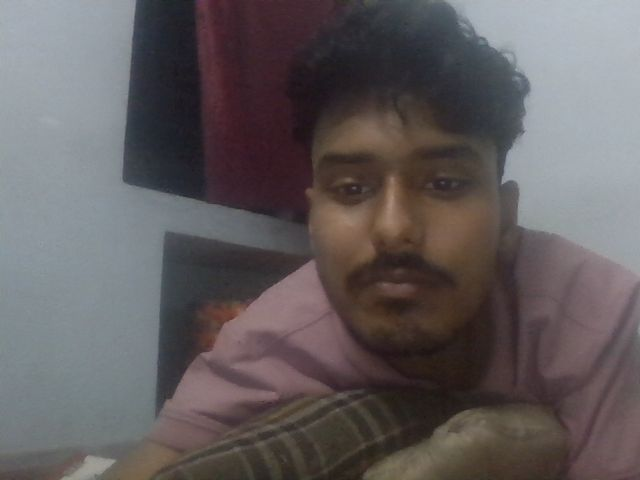

In [81]:
from IPython.display import Image
try:
  filename = take_photo()
  print('Saved to {}'.format(filename))

  # Show the image which was just taken.
  display(Image(filename))
except Exception as err:
  # Errors will be thrown if the user does not have a webcam or if they do not
  # grant the page permission to access it.
  print(str(err))

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

def recommend_by_emotion(detected_emotion, top_n=10):

    if detected_emotion not in emotion_to_mood:
        raise ValueError(f"Unknown emotion: {detected_emotion}")

    mood = emotion_to_mood[detected_emotion]

    # Get songs belonging to the required mood
    mood_songs = spotify[spotify["Mood"] == mood].copy()

    if len(mood_songs) == 0:
        return pd.DataFrame()

    # Create mood vector
    mood_vector = np.array(
        [[mood_profiles[mood][feature] for feature in features]]
    )

    # Get features of mood songs
    song_features = mood_songs[features].to_numpy()

    # Scale them using our existing scaler
    song_scaled = scaler.transform(song_features)
    mood_scaled = scaler.transform(mood_vector)

    # Calculate similarity
    similarities = cosine_similarity(
        mood_scaled,
        song_scaled
    )[0]

    mood_songs["Similarity"] = similarities

    # Normalize popularity to 0-1
    mood_songs["Popularity_Score"] = (
        mood_songs["Popularity"] / 100
    )

    # Combined recommendation score
    mood_songs["Recommendation_Score"] = (
        0.6 * mood_songs["Similarity"]
        + 0.4 * mood_songs["Popularity_Score"]
    )

    # Sort by final score
    recommendations = mood_songs.sort_values(
        "Recommendation_Score",
        ascending=False
    ).head(top_n)

    return recommendations[
        [
            "Track Name",
            "Artist Name(s)",
            "Popularity",
            "Similarity",
            "Recommendation_Score",
            "Mood"
        ]
    ]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
✅ Detected Emotion: Sad

Top Song Recommendations:


,Track Name,Artist Name(s),Popularity,Similarity,Recommendation_Score,Mood
2856,I Will Always Love You,Whitney Houston,77,0.973426,0.892056,Sad
682,When I Was Your Man,Bruno Mars,88,0.883292,0.881975,Sad
1141,Imagine - Remastered 2010,John Lennon,76,0.959027,0.879416,Sad
5453,lovely (with Khalid),"Billie Eilish, Khalid",86,0.886513,0.875908,Sad
1661,Stay With Me,Sam Smith,82,0.912311,0.875387,Sad
1107,Arcade,Duncan Laurence,73,0.956337,0.865802,Sad
9970,Come Away With Me,Norah Jones,71,0.958457,0.859074,Sad
9466,Photograph,Ed Sheeran,84,0.870688,0.858413,Sad
5233,"My Heart Will Go On - Love Theme from ""Titanic""",Céline Dion,73,0.933449,0.852069,Sad
2350,Can't Help Falling in Love,Elvis Presley,79,0.893223,0.851934,Sad


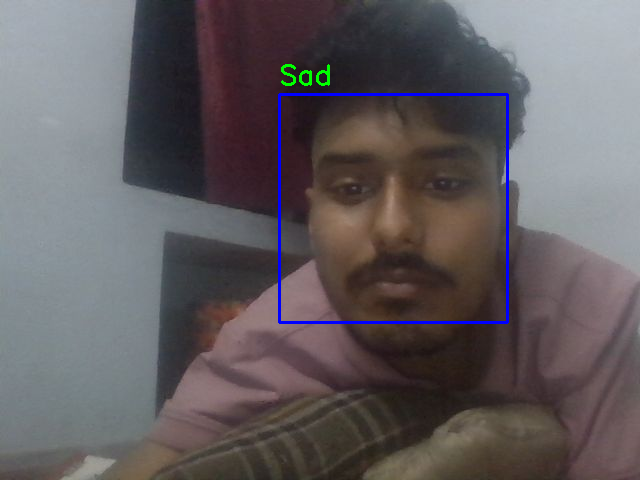

In [87]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Load the photo you just captured
image_path = 'photo.jpg'
frame = cv2.imread(image_path)

if frame is None:
    print("Error: photo.jpg not found. Make sure you ran the capture cell above.")
else:
    # Convert to grayscale for face detection and emotion model
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_classifier.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

    if len(faces) == 0:
        print("No face detected in the photo. Try running the camera capture cell again.")

    for (x, y, w, h) in faces:
        # Draw bounding box around face
        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)

        # Crop, resize, and normalize the face region
        roi_gray = gray[y:y+h, x:x+w]
        roi_gray = cv2.resize(roi_gray, (48, 48))
        roi = roi_gray.astype('float') / 255.0
        roi = np.expand_dims(roi, axis=0)
        roi = np.expand_dims(roi, axis=-1)

        # Predict the emotion using your trained model
        prediction = model.predict(roi)[0]
        label = emotion_labels[prediction.argmax()]

        # Overlay the predicted emotion label on the image
        cv2.putText(frame, label, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

        # Output results
        print(f"✅ Detected Emotion: {label}")
        print("\nTop Song Recommendations:")

        # Fetch and display recommendations based on the detected emotion
        recommendations = recommend_by_emotion(label, top_n=10)
        display(recommendations)

    # Show the processed image with the bounding box and label
    cv2_imshow(frame)